In [ ]:
from backtest_engine import request, Portfolio, PortfolioDynamicCost, StrategyConnector, generate_toy_equity
from datetime import date
import tomllib

with open("config.toml", "rb") as f:
    config = tomllib.load(f)["alpaca-api"]
    
df = request(
    ticker="SPY",
    config=config,
)

Loading data from local cache: cache_SPY_20170101_20260620.parquet


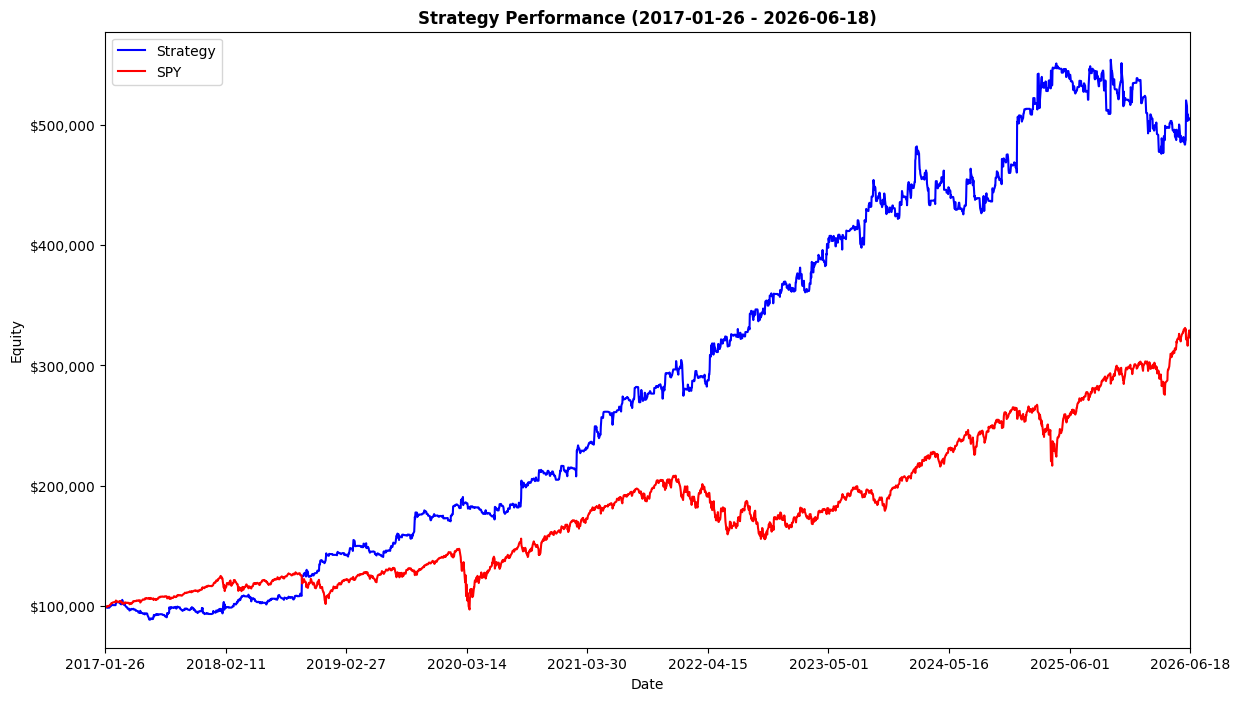

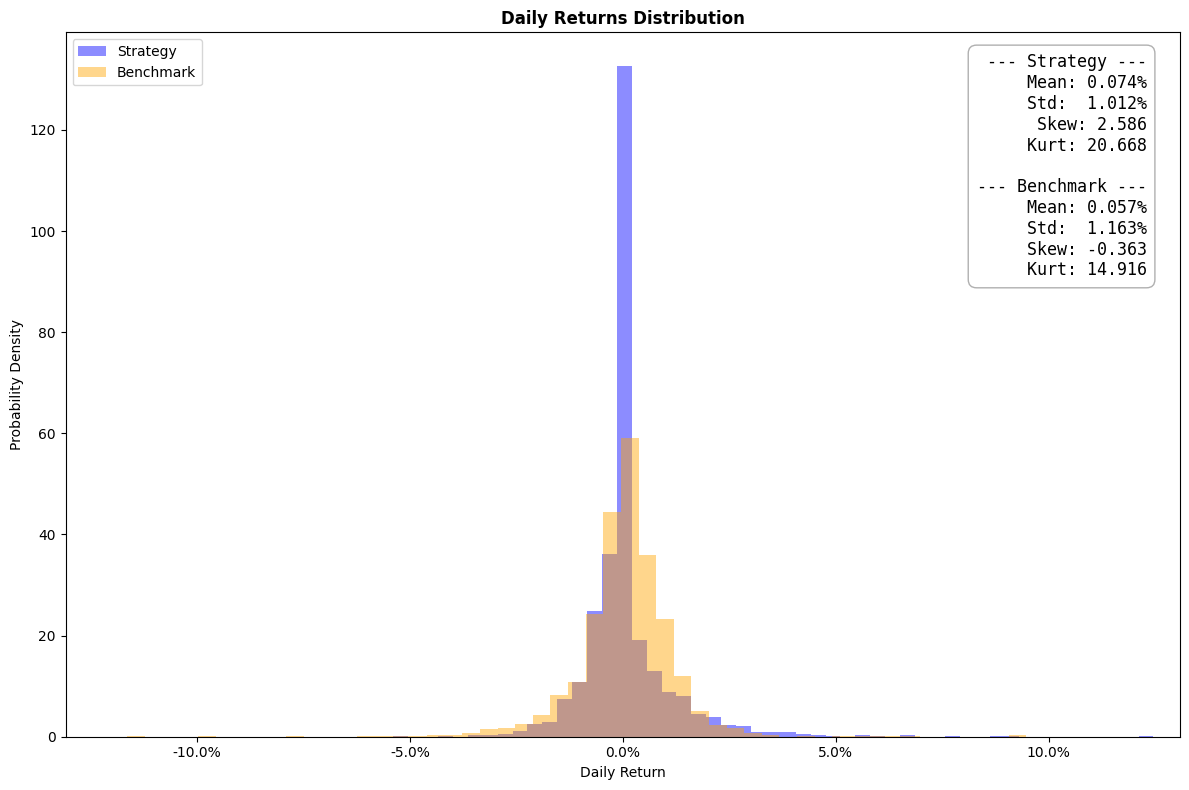

                                Strategy      Benchmark
Total Days                         2,362
Cum. Return                      404.60%        230.32%
Ann. Return                       18.85%         13.60%
Avg. Daily Return                  0.07%          0.06%
Ret. Skew                           2.59          -0.36
Ret. Kurtosis                      20.67          14.92
Max Gain                          12.46%          9.47%
Best Day                      2018-10-10     2020-03-24
Max Loss                          -5.39%        -11.63%
Worst Day                     2018-02-06     2020-03-16
Win Rate                          42.10%              -
Daily Win Rate                    29.68%         55.63%
Average Trades / Day                1.00              -
Average Return / Trade              0.00              -
Alpha                               0.20              -
Beta                               -0.10              -
R-Squared                           0.01              -
Ann. Vo

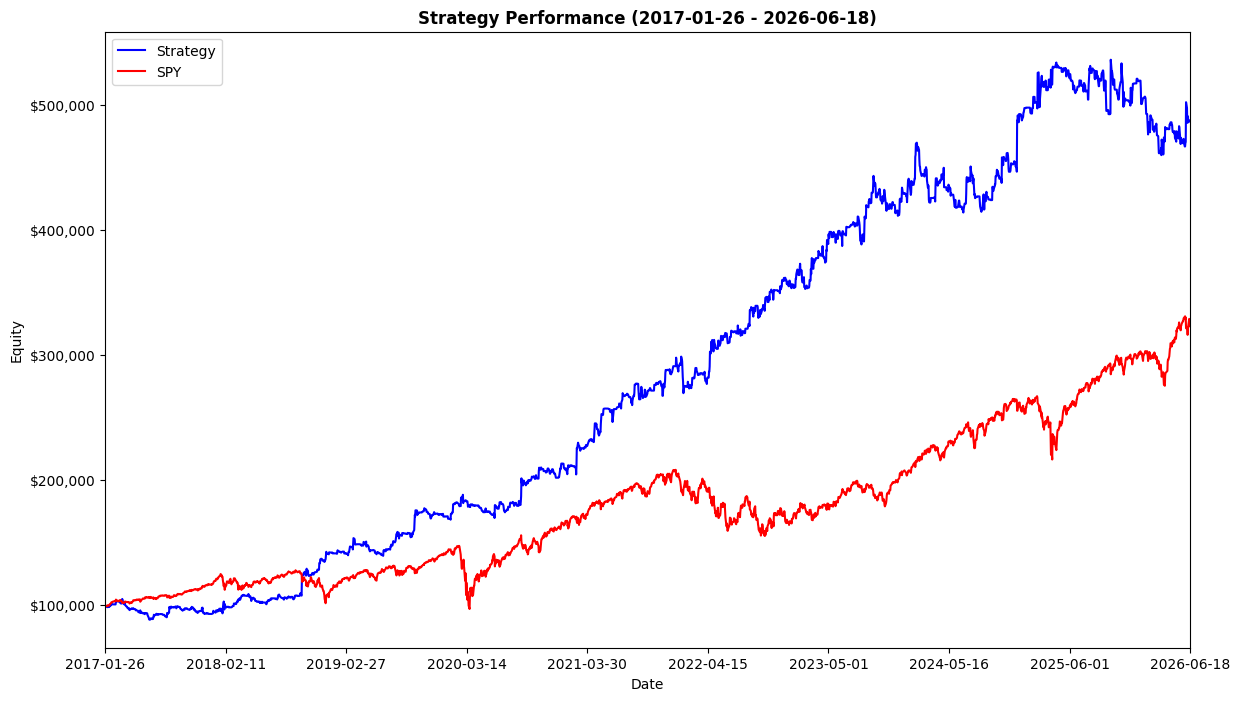

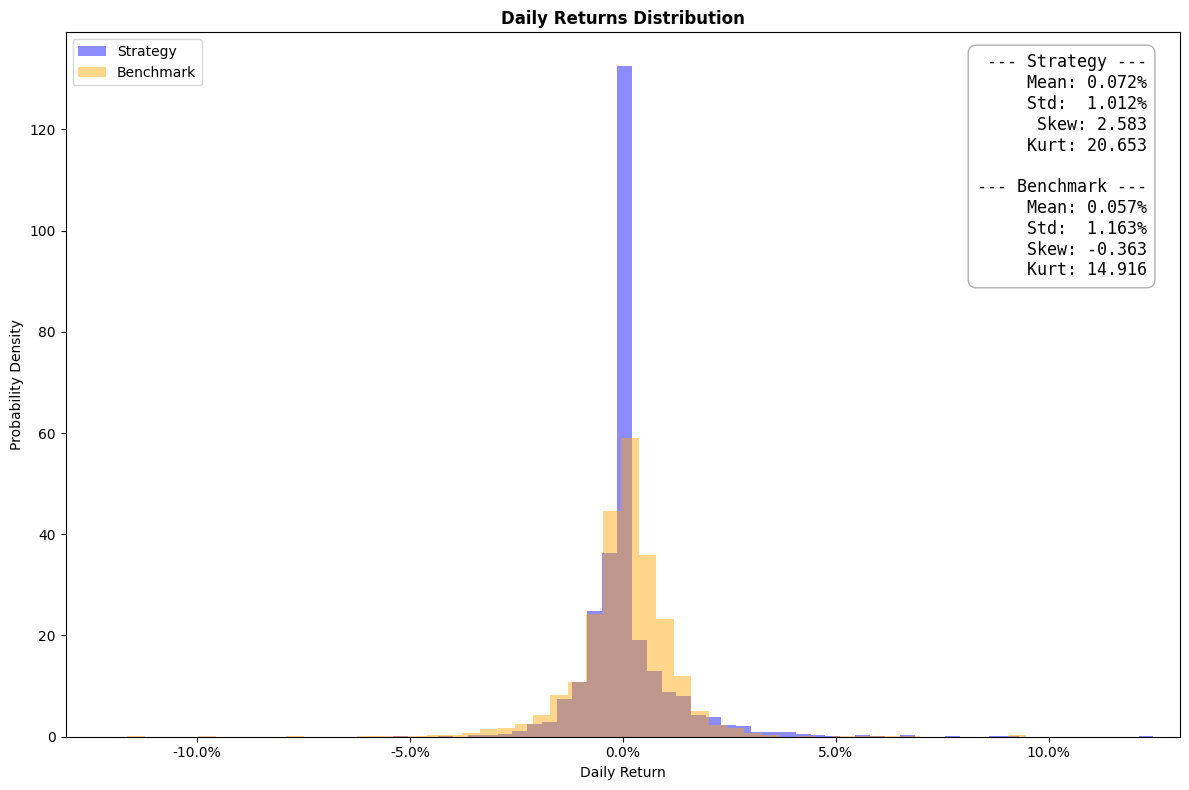

                                Strategy      Benchmark
Total Days                         2,362
Cum. Return                      387.20%        230.32%
Ann. Return                       18.41%         13.60%
Avg. Daily Return                  0.07%          0.06%
Ret. Skew                           2.58          -0.36
Ret. Kurtosis                      20.65          14.92
Max Gain                          12.46%          9.47%
Best Day                      2018-10-10     2020-03-24
Max Loss                          -5.39%        -11.63%
Worst Day                     2018-02-06     2020-03-16
Win Rate                          42.02%              -
Daily Win Rate                    29.59%         55.63%
Average Trades / Day                1.00              -
Average Return / Trade              0.00              -
Alpha                               0.20              -
Beta                               -0.10              -
R-Squared                           0.01              -
Ann. Vo

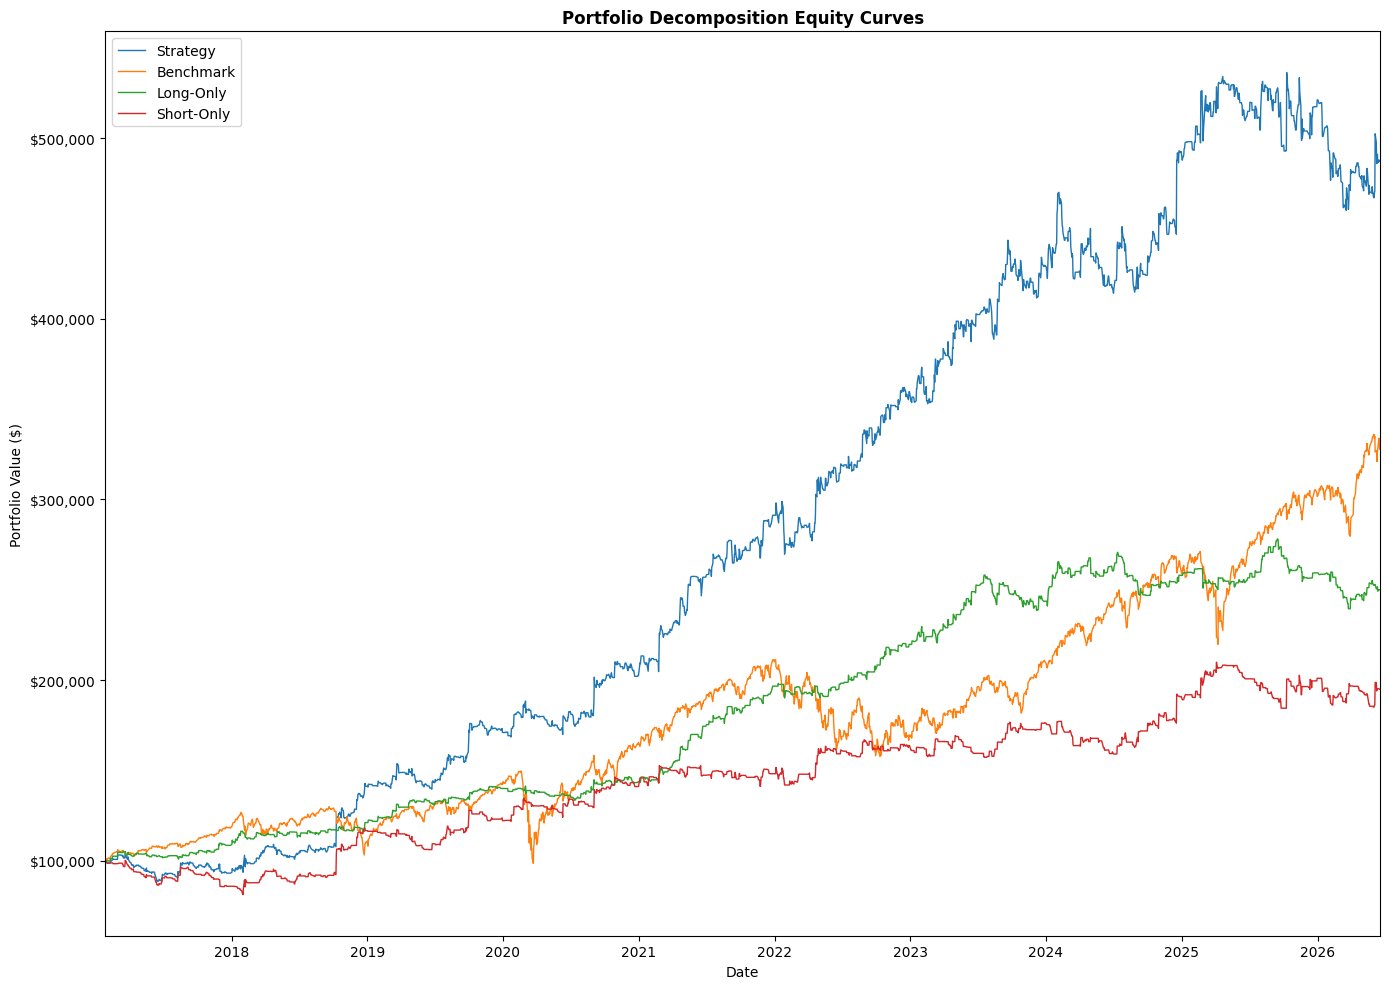

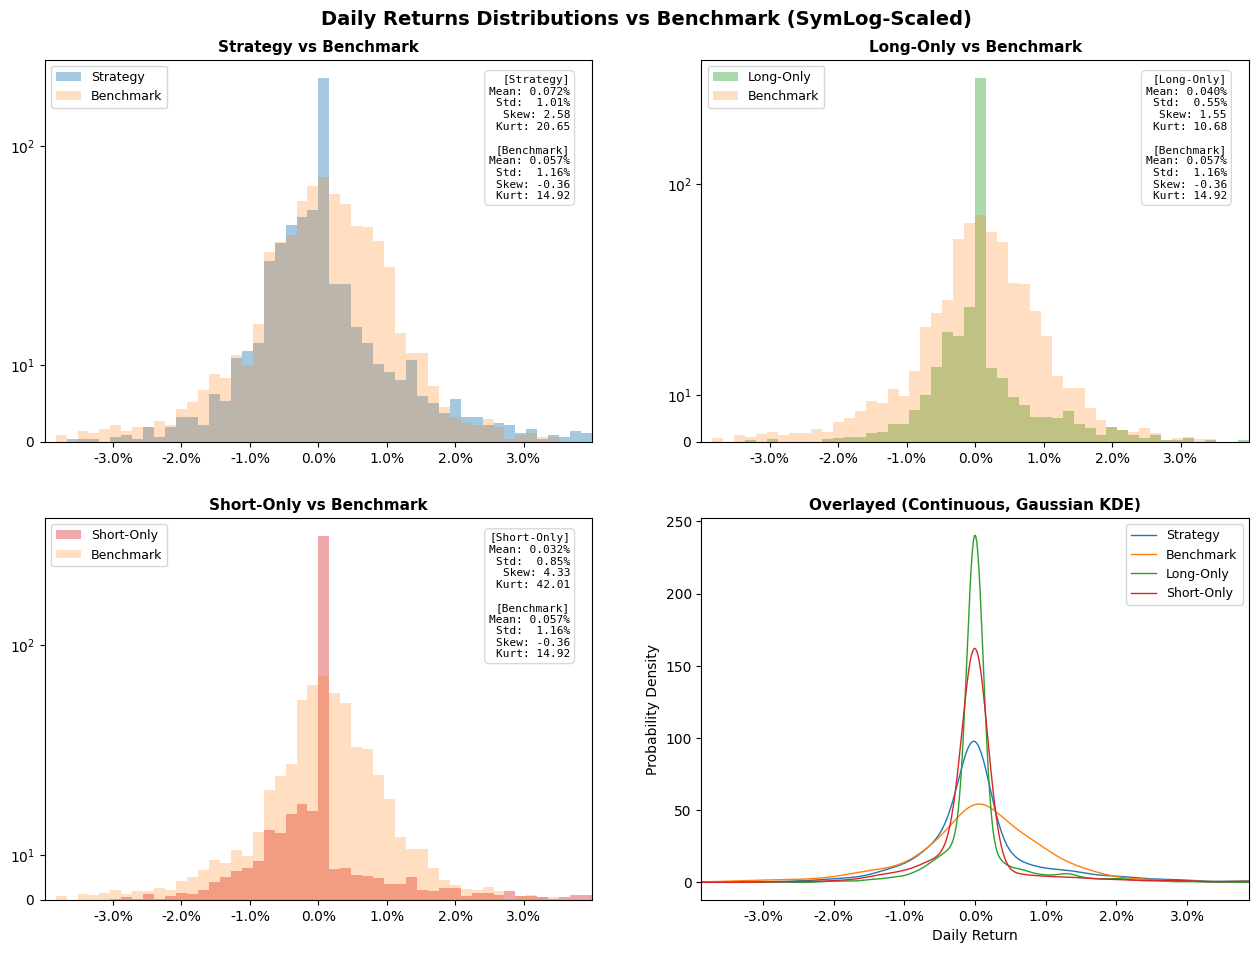

                                Strategy     Strat_Long     Short-Only      Benchmark
-------------------------------------------------------------------------------------
Total Days                         2,362          2,362          2,362              -
Cum. Return                      387.20%        150.03%         94.86%        230.32%
Ann. Return                       18.41%         10.27%          7.38%         13.60%
Avg. Daily Return                  0.07%          0.04%          0.03%          0.06%
Ret. Skew                           2.58           1.55           4.33          -0.36
Ret. Kurtosis                      20.65          10.68          42.01          14.92
Max Gain                          12.46%          4.21%         12.46%          9.47%
Best Day                      2018-10-10     2018-12-26     2018-10-10     2020-03-24
Max Loss                          -5.39%         -3.22%         -4.28%        -11.63%
Worst Day                     2018-02-06     2024-05-0

In [2]:

pn = Portfolio(df)
p = PortfolioDynamicCost(df)

toy_book = generate_toy_equity(p, expected_return=0.15, volatility=0.075)

c = StrategyConnector(p, toy_book, df["close"])

print(pn.result())
print(p.result())
print(p.result(decompose=True)) 
# print(p.result(start=date(2020, 1, 1), end=date(2021, 1, 1)))
# print(p.result(day=date(2025, 4, 12)))


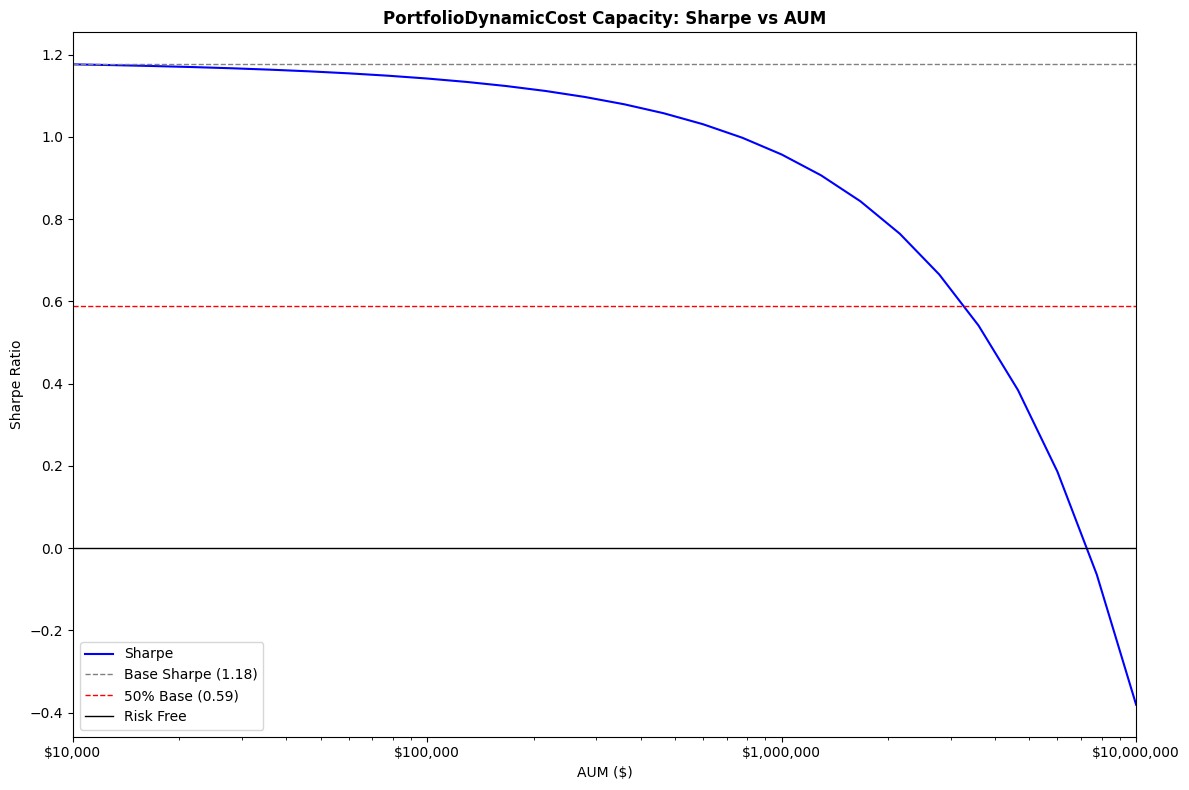

In [3]:
PortfolioDynamicCost.sharpe_curve(df, max_aum=10_000_000)

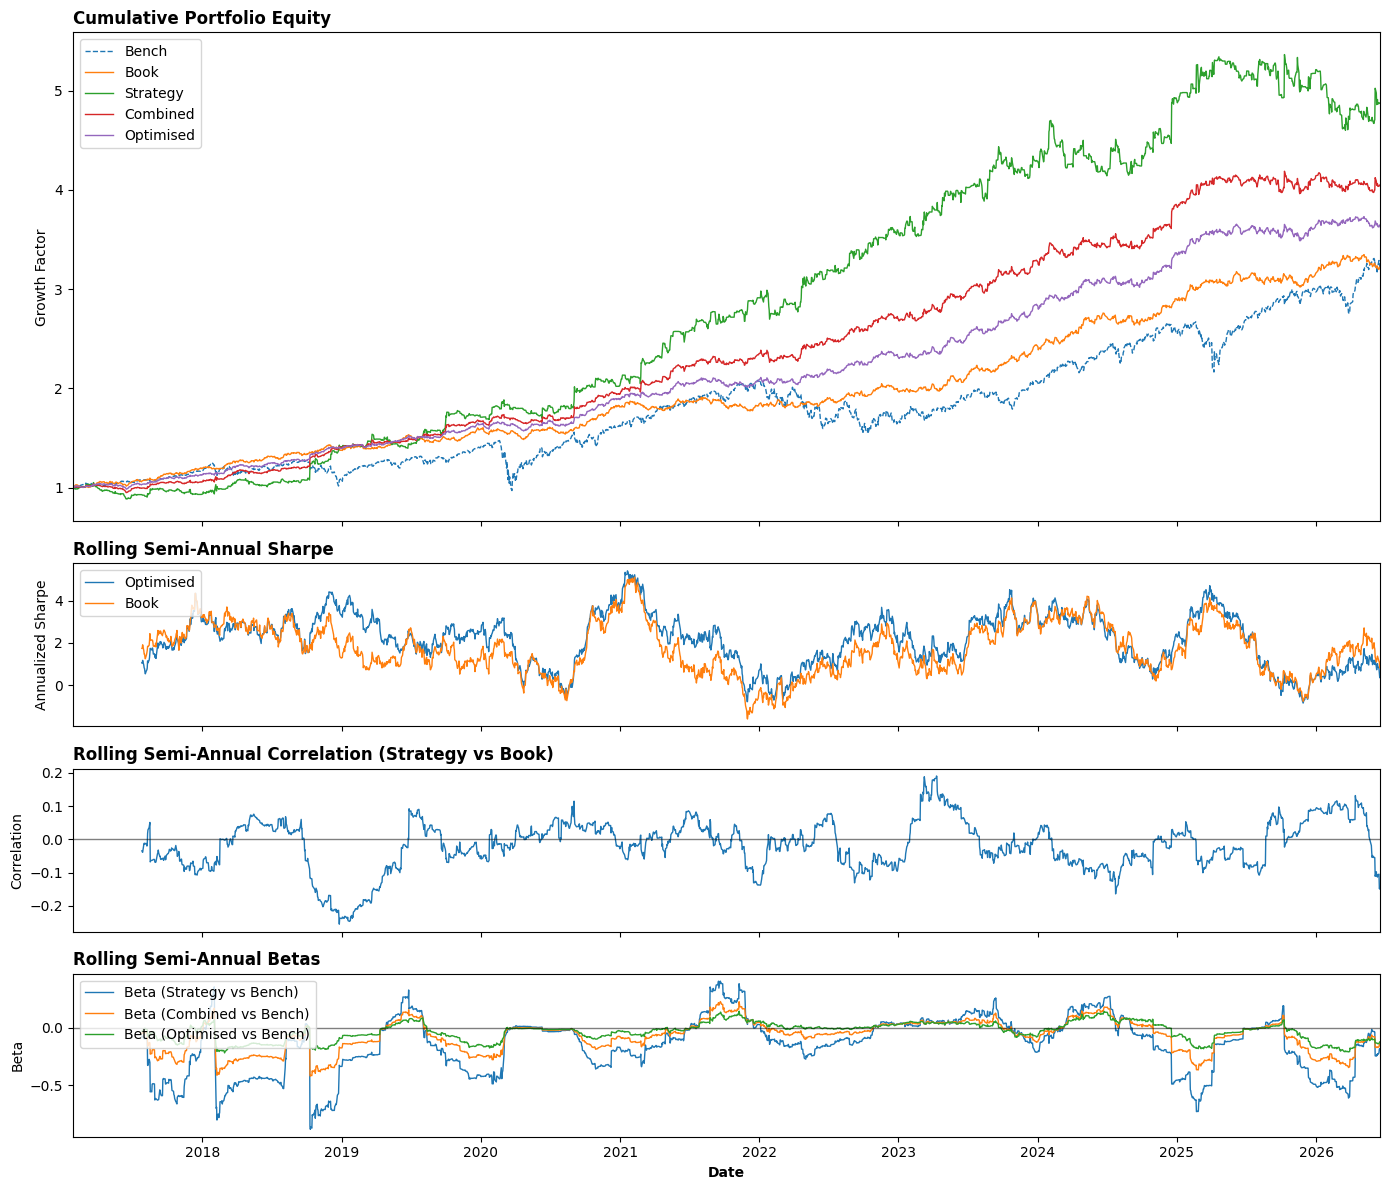

=== Portfolio Integration & Risk Report ===
                                 Book Strategy   Combined Optimised    Bench
Expected Return                12.75%   18.17%     15.30%    14.02%   14.30%
Volatility                      7.56%   16.07%      8.79%     6.84%   18.45%
Sharpe Ratio                     1.69     1.13       1.74      2.05     0.77
Beta                             0.00    -0.10      -0.05     -0.02     1.00
Skewness                        -0.03     2.58       1.73      0.28    -0.36
Kurtosis                         0.06    20.65      12.47      1.26    14.94
Max Drawdown                   -7.46%  -15.81%     -8.48%    -5.57%  -34.23%
Max DD Days                       260      255        172       144      512
Max DD Recovery Days               47      195         56        20      103
Correlation to Book                 -    -0.03       0.40      0.82        -
Crash Correlation to Book           -    -0.04       0.16      0.51        -
Intraday Correlation to Book    

In [4]:
c.result()

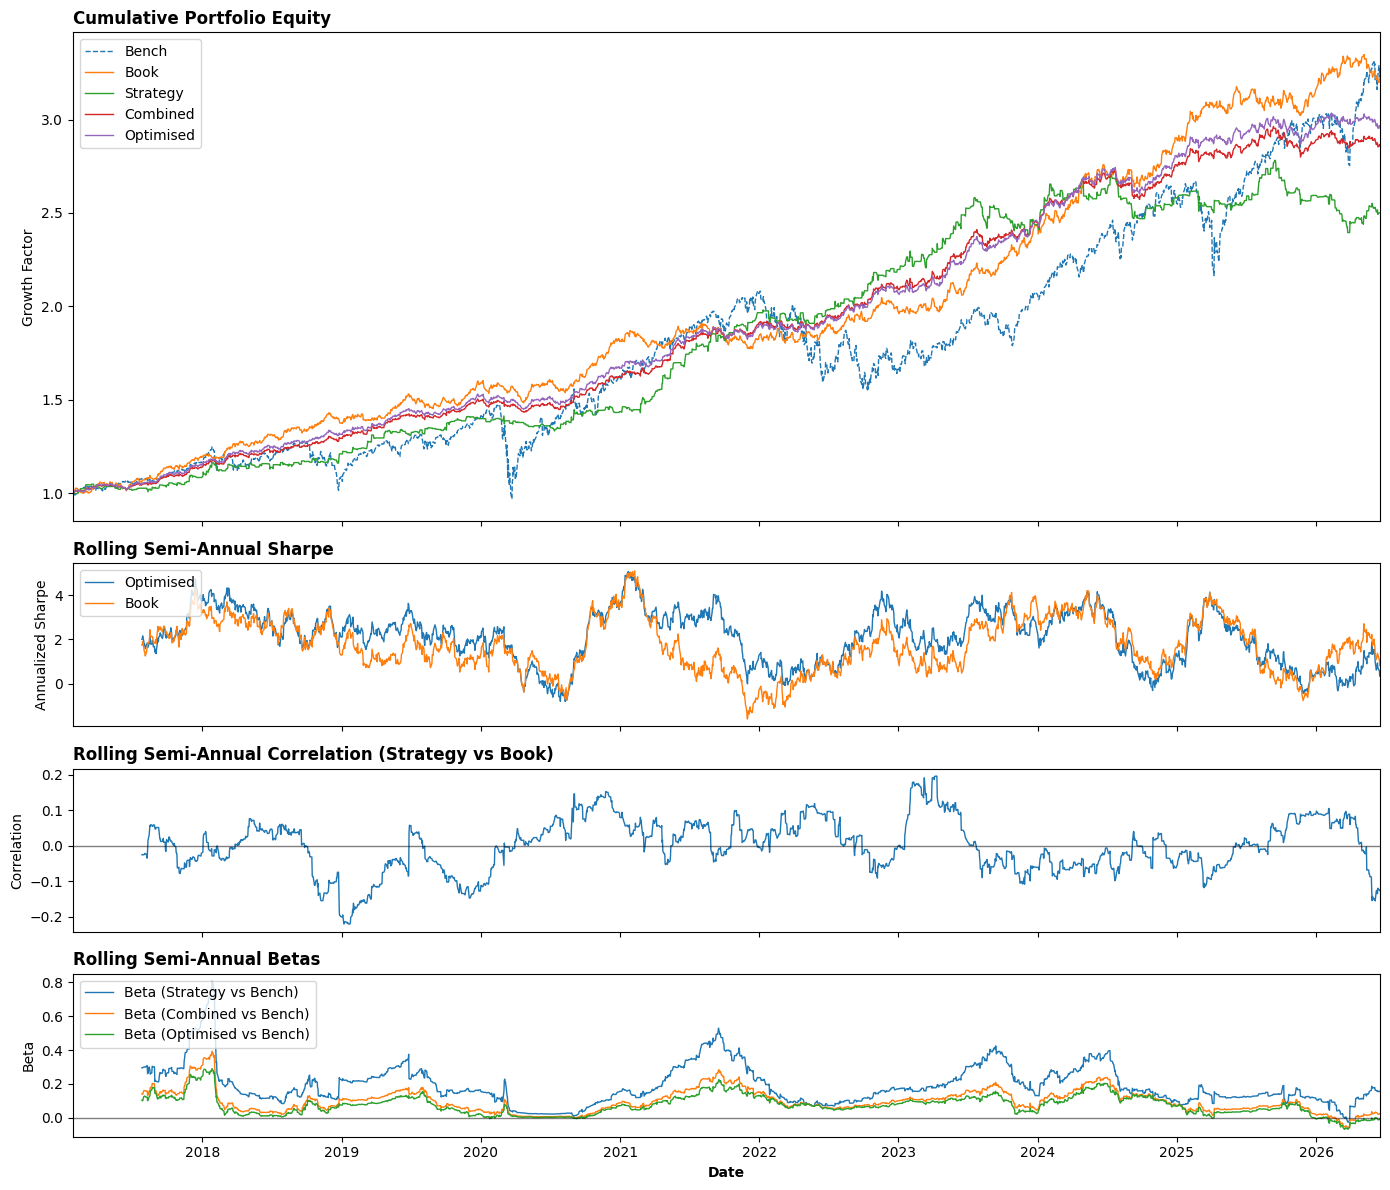

=== Portfolio Integration & Risk Report ===
                                 Book Strategy   Combined Optimised    Bench
Expected Return                12.75%   10.15%     11.39%    11.76%   14.30%
Volatility                      7.56%    8.65%      5.73%     5.72%   18.45%
Sharpe Ratio                     1.69     1.17       1.99      2.06     0.77
Beta                             0.00     0.12       0.06      0.05     1.00
Skewness                        -0.03     1.55       0.55      0.20    -0.36
Kurtosis                         0.06    10.68       2.64      0.68    14.94
Max Drawdown                   -7.46%  -13.89%     -5.74%    -5.33%  -34.23%
Max DD Days                       260      278        193       173      512
Max DD Recovery Days               47       60         63        92      103
Correlation to Book                 -    -0.00       0.66      0.82        -
Crash Correlation to Book           -    -0.02       0.36      0.55        -
Intraday Correlation to Book    

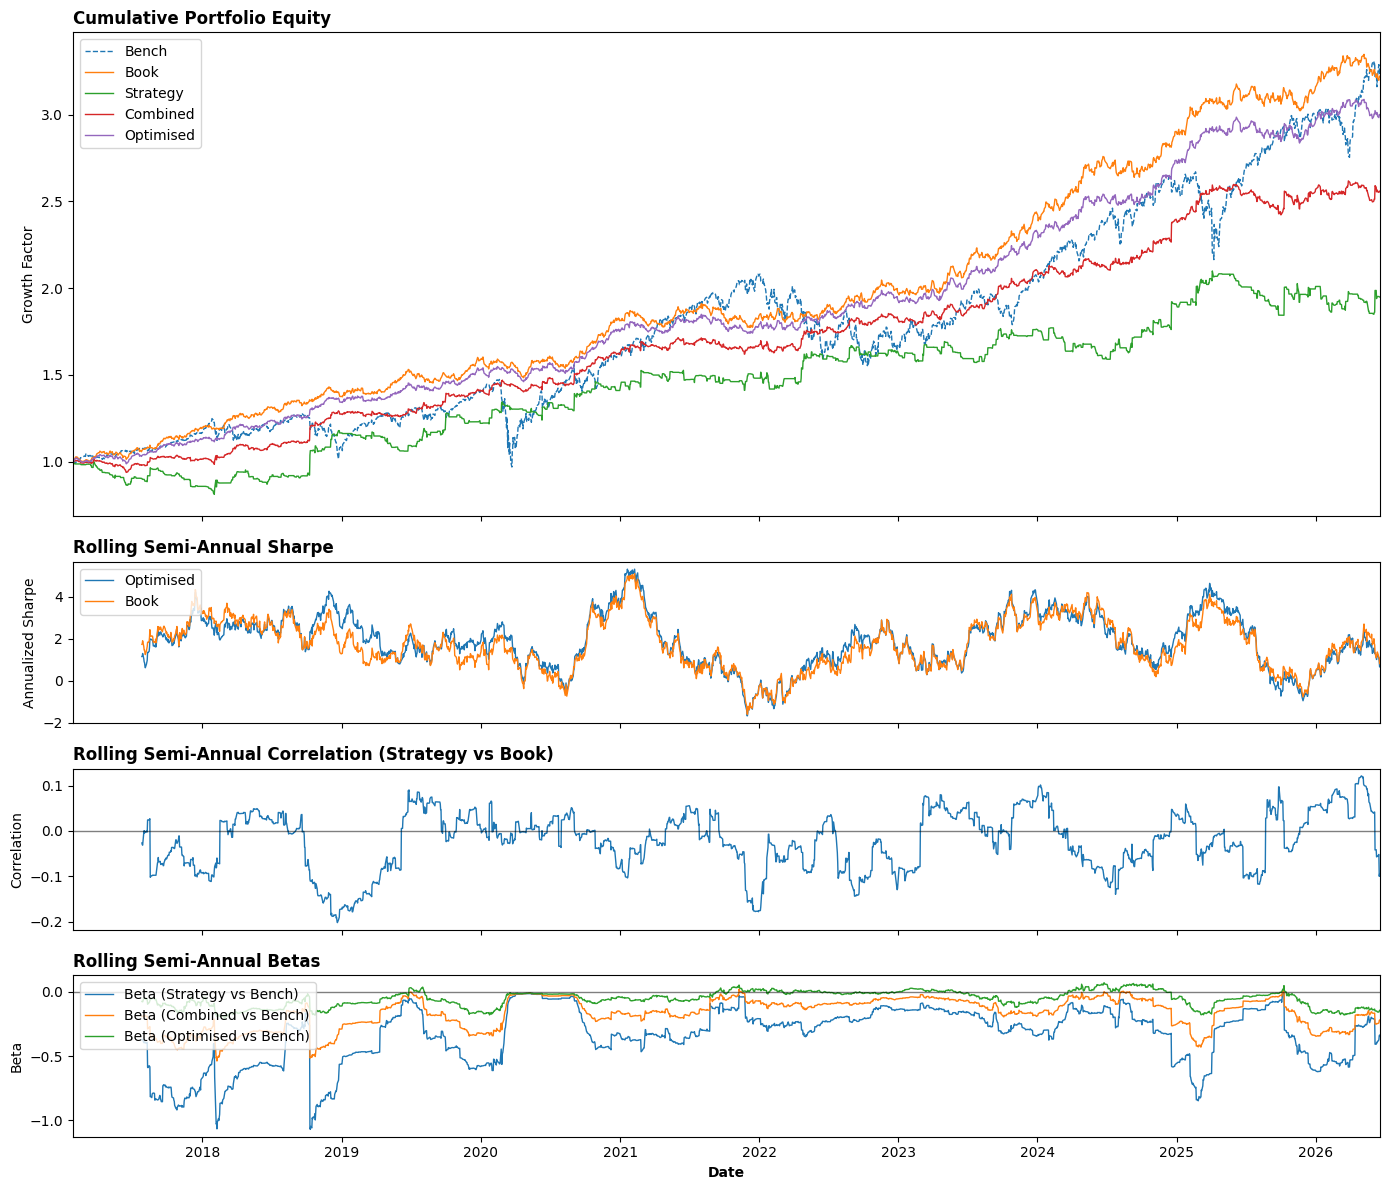

=== Portfolio Integration & Risk Report ===
                                 Book Strategy   Combined Optimised    Bench
Expected Return                12.75%    8.01%     10.31%    11.93%   14.30%
Volatility                      7.56%   13.53%      7.64%     6.62%   18.45%
Sharpe Ratio                     1.69     0.59       1.35      1.80     0.77
Beta                             0.00    -0.22      -0.11     -0.04     1.00
Skewness                        -0.03     4.33       2.66      0.07    -0.36
Kurtosis                         0.06    42.01      22.35      0.34    14.94
Max Drawdown                   -7.46%  -18.94%     -7.36%    -5.94%  -34.23%
Max DD Days                       260      392        226       226      512
Max DD Recovery Days               47      174         44       142      103
Correlation to Book                 -    -0.03       0.47      0.94        -
Crash Correlation to Book           -    -0.04       0.19      0.73        -
Intraday Correlation to Book    

In [5]:
pl = PortfolioDynamicCost(df, short_permissions=False)
ps = PortfolioDynamicCost(df, long_permissions=False)

plc = StrategyConnector(pl, toy_book, df["close"])
psc = StrategyConnector(ps, toy_book, df["close"])

plc.result()
psc.result()

SEED 243


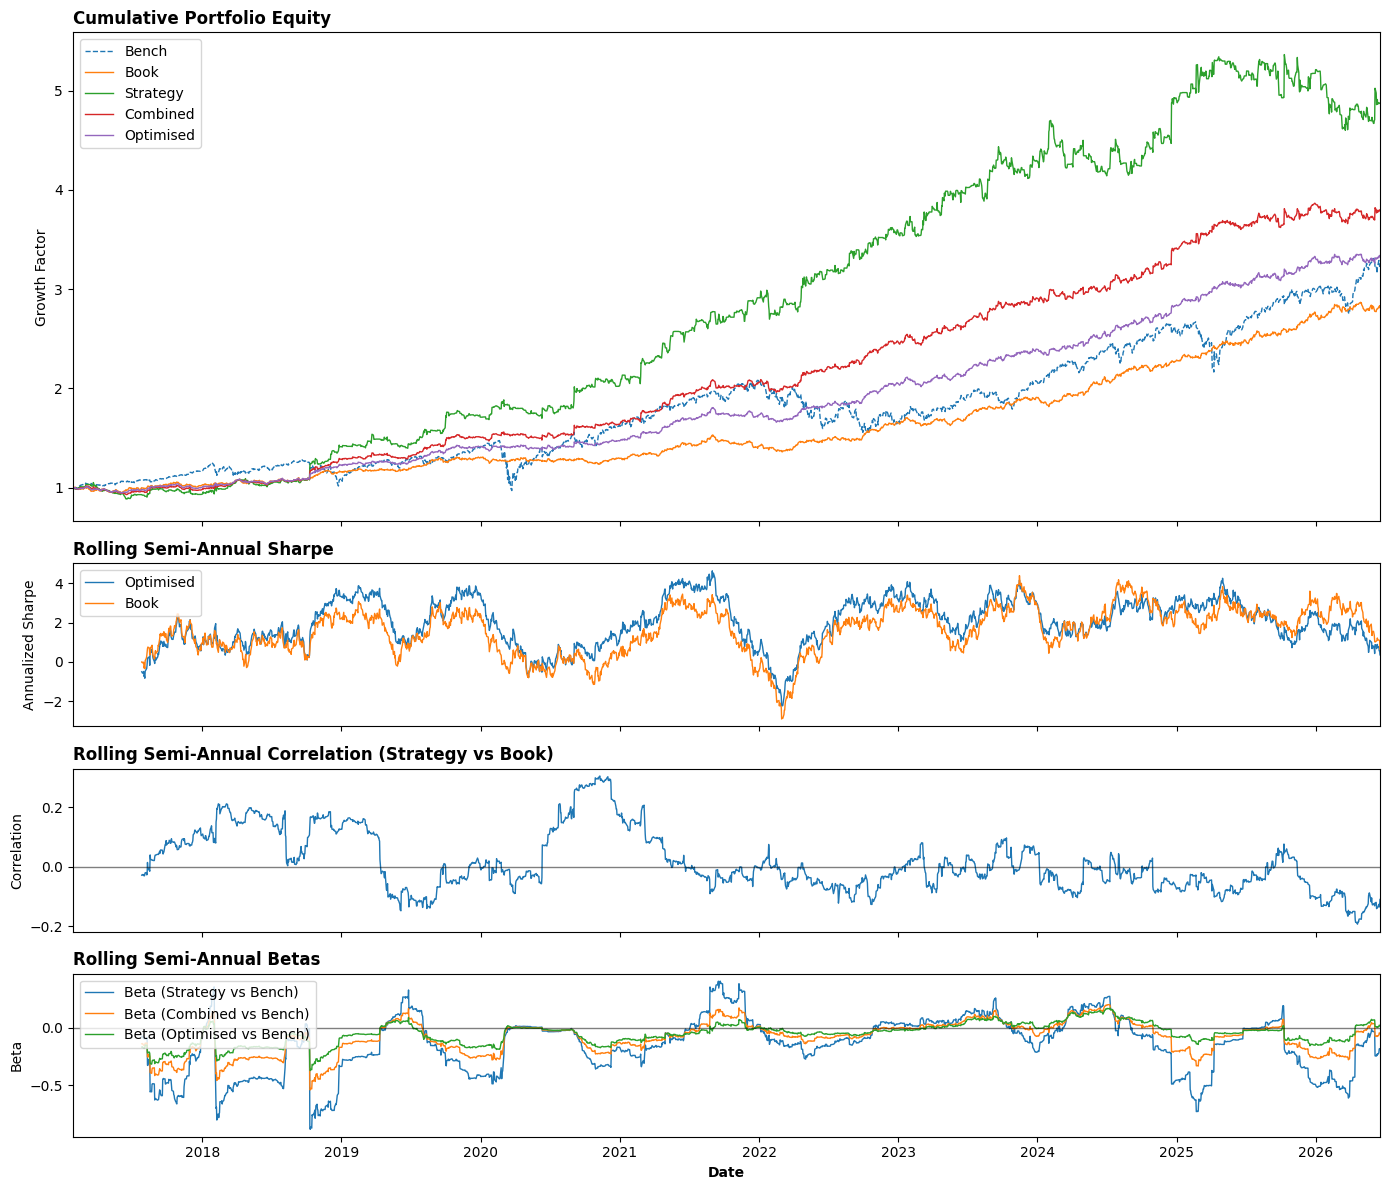

=== Portfolio Integration & Risk Report ===
                                  Book Strategy   Combined Optimised    Bench
Expected Return                 11.32%   18.17%     14.60%    13.06%   14.30%
Volatility                       7.57%   16.07%      8.94%     7.03%   18.45%
Sharpe Ratio                      1.50     1.13       1.63      1.86     0.77
Beta                             -0.02    -0.10      -0.06     -0.04     1.00
Skewness                          0.07     2.58       1.95      0.61    -0.36
Kurtosis                         -0.01    20.65      15.20      3.57    14.94
Max Drawdown                   -11.04%  -15.81%     -8.51%    -8.19%  -34.23%
Max DD Days                        274      255        162       171      512
Max DD Recovery Days               148      195         92        56      103
Correlation to Book                  -     0.01       0.44      0.81        -
Crash Correlation to Book            -     0.04       0.22      0.51        -
Intraday Correlation

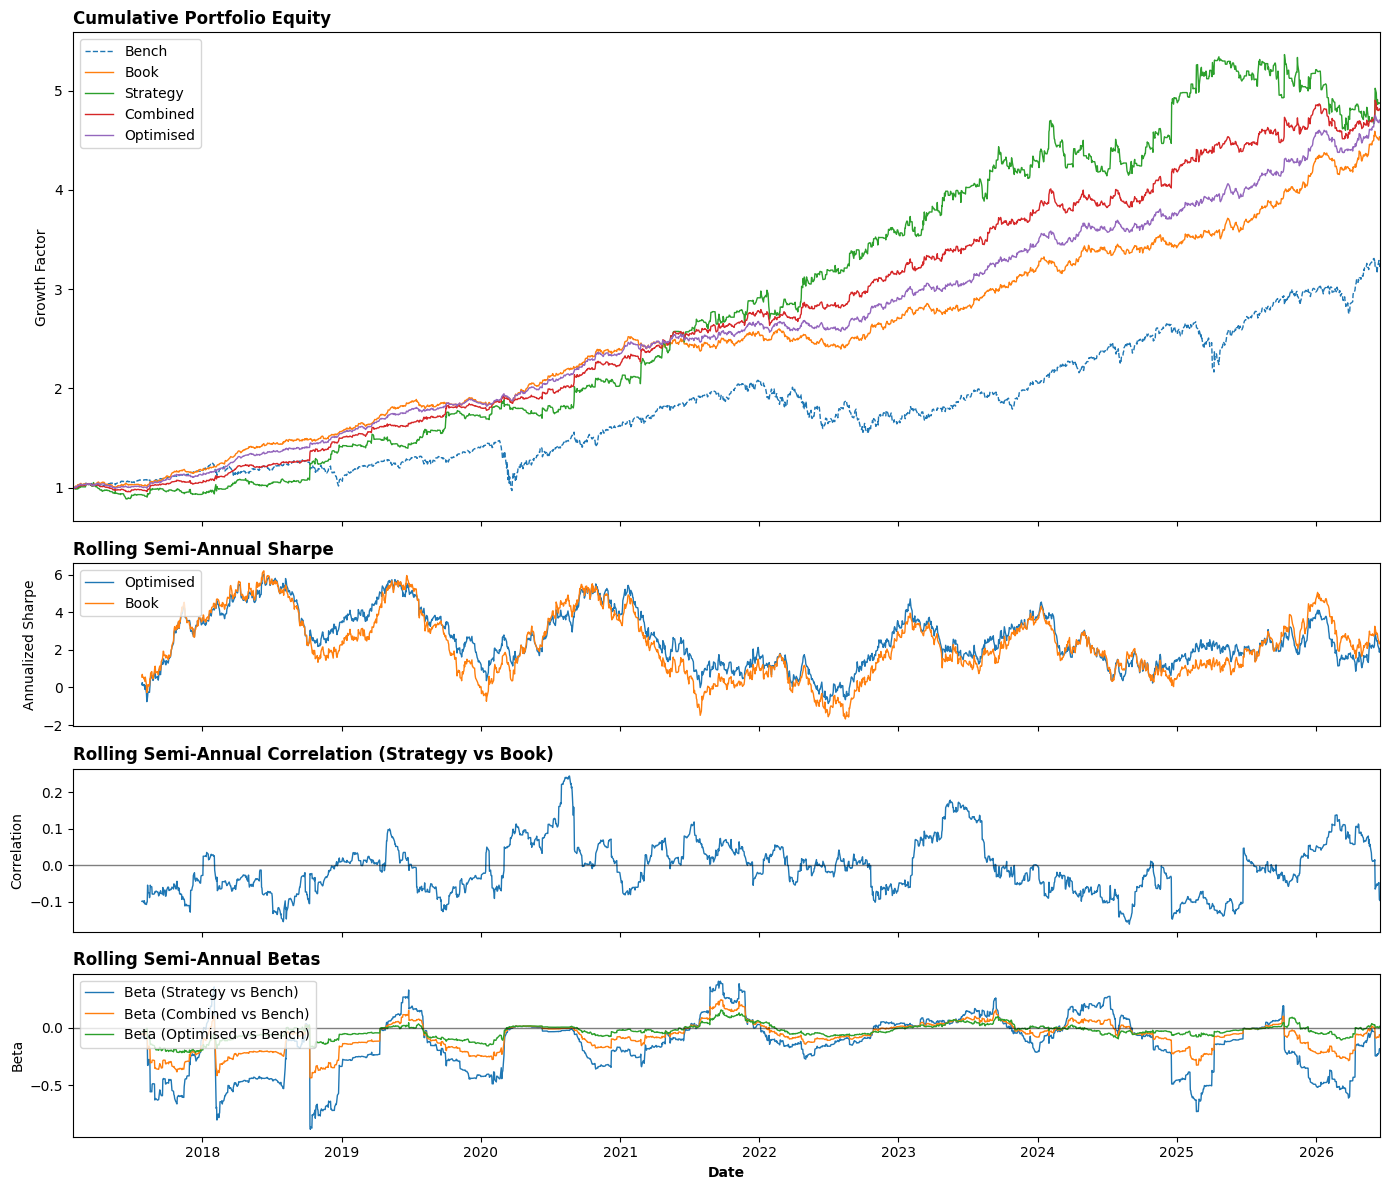

=== Portfolio Integration & Risk Report ===
                                 Book Strategy   Combined Optimised    Bench
Expected Return                16.41%   18.17%     17.16%    16.75%   14.30%
Volatility                      7.42%   16.07%      8.78%     6.69%   18.45%
Sharpe Ratio                     2.21     1.13       1.95      2.50     0.77
Beta                             0.00    -0.10      -0.05     -0.02     1.00
Skewness                         0.04     2.58       1.78      0.17    -0.36
Kurtosis                        -0.01    20.65      13.44      0.63    14.94
Max Drawdown                   -7.84%  -15.81%     -7.66%    -4.96%  -34.23%
Max DD Days                       212      255        186        94      512
Max DD Recovery Days               56      195         64        65      103
Correlation to Book                 -    -0.02       0.41      0.89        -
Crash Correlation to Book           -    -0.02       0.14      0.54        -
Intraday Correlation to Book    

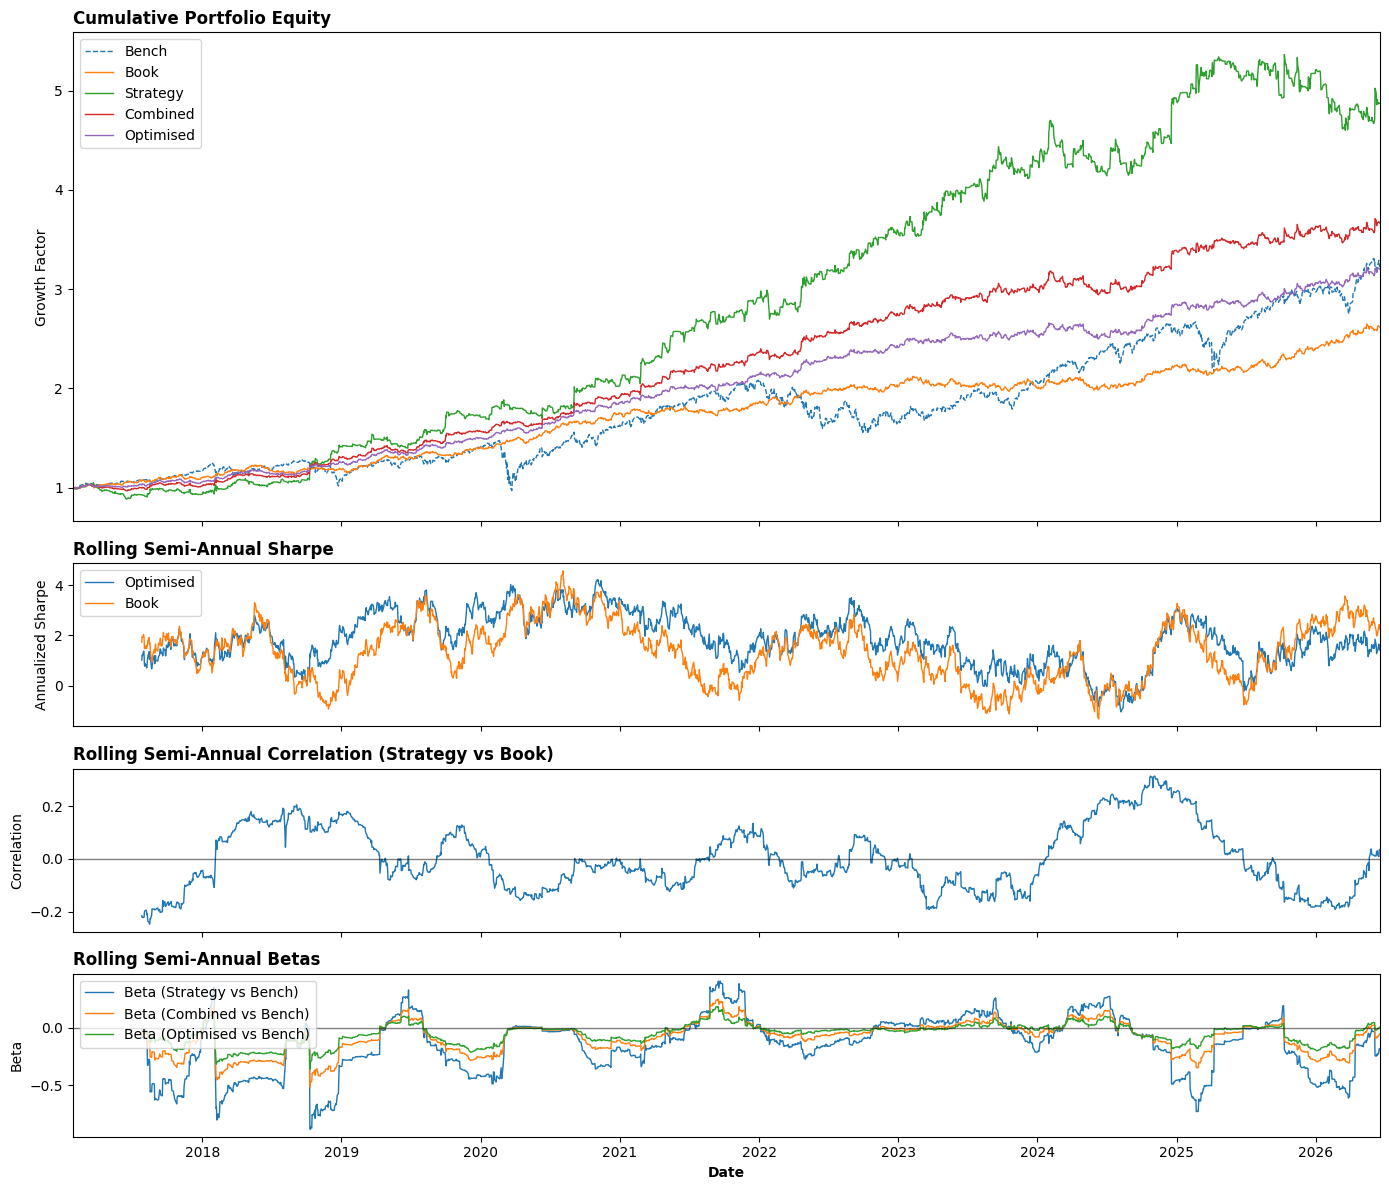

=== Portfolio Integration & Risk Report ===
                                 Book Strategy   Combined Optimised    Bench
Expected Return                10.54%   18.17%     14.26%    12.66%   14.30%
Volatility                      7.58%   16.07%      8.90%     7.08%   18.45%
Sharpe Ratio                     1.39     1.13       1.60      1.79     0.77
Beta                            -0.01    -0.10      -0.05     -0.03     1.00
Skewness                        -0.02     2.58       2.01      0.76    -0.36
Kurtosis                        -0.03    20.65      14.93      4.02    14.94
Max Drawdown                   -7.23%  -15.81%     -7.53%    -6.06%  -34.23%
Max DD Days                       417      255        186       174      512
Max DD Recovery Days              131      195        100        85      103
Correlation to Book                 -     0.01       0.43      0.78        -
Crash Correlation to Book           -    -0.06       0.17      0.48        -
Intraday Correlation to Book    

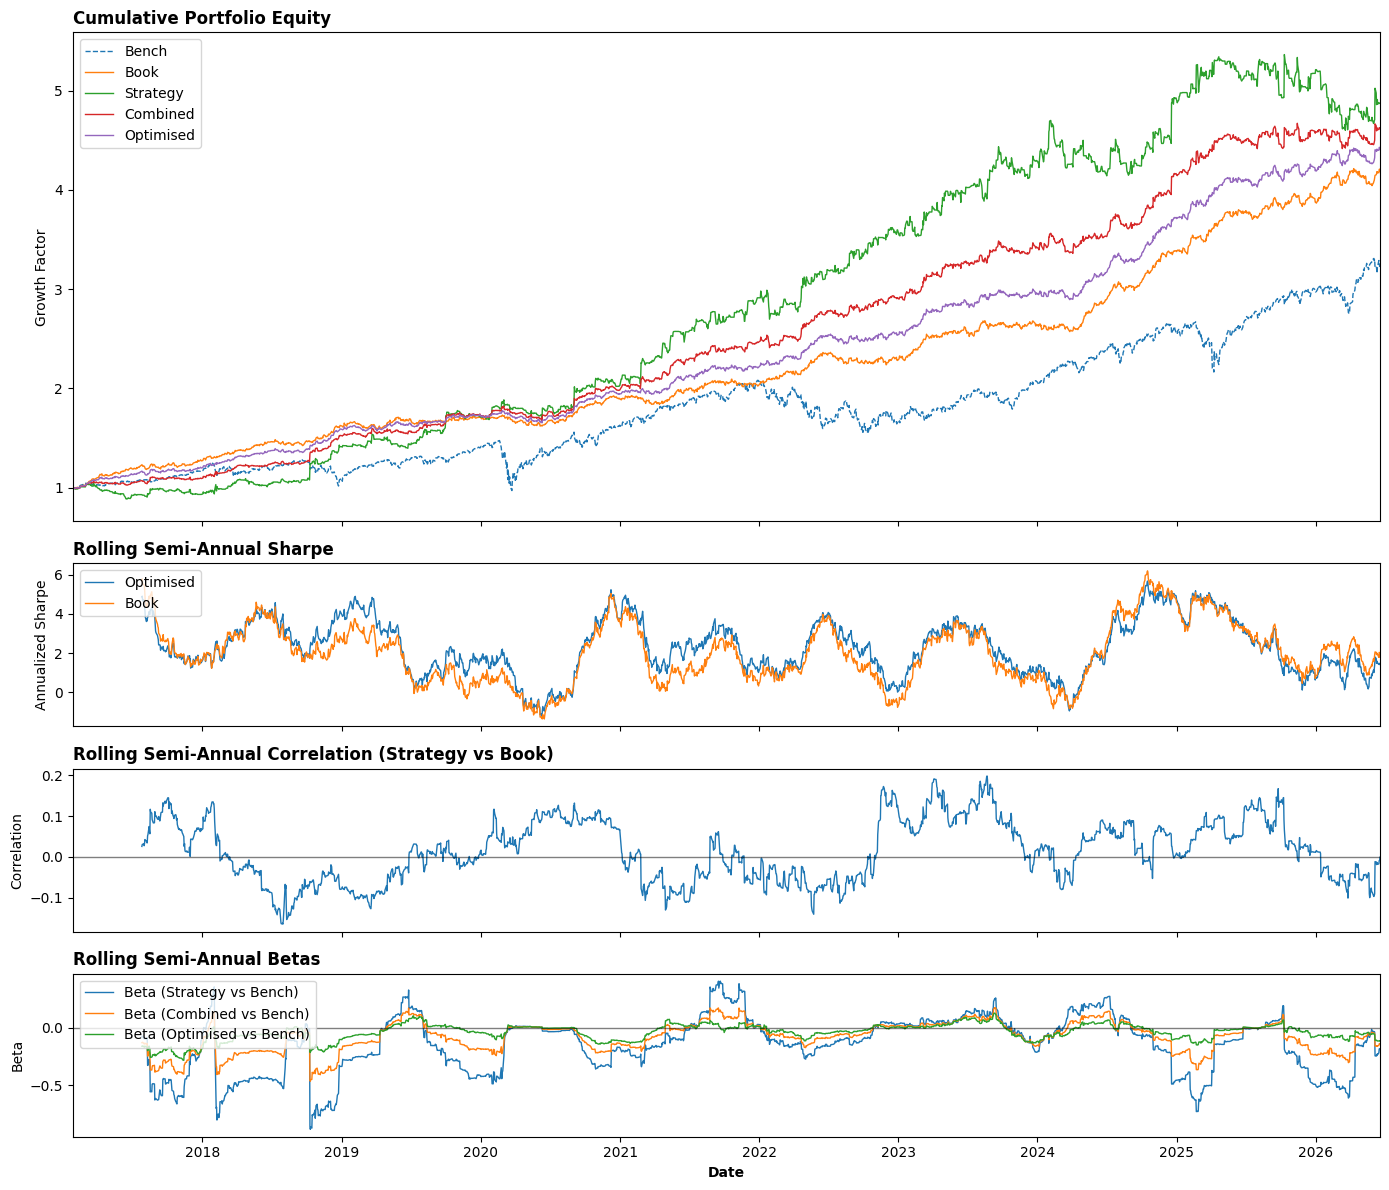

=== Portfolio Integration & Risk Report ===
                                 Book Strategy   Combined Optimised    Bench
Expected Return                15.58%   18.17%     16.72%    16.08%   14.30%
Volatility                      7.54%   16.07%      8.91%     6.86%   18.45%
Sharpe Ratio                     2.07     1.13       1.88      2.35     0.77
Beta                            -0.01    -0.10      -0.05     -0.02     1.00
Skewness                         0.02     2.58       1.91      0.27    -0.36
Kurtosis                         0.07    20.65      13.38      0.83    14.94
Max Drawdown                   -6.41%  -15.81%     -7.84%    -6.90%  -34.23%
Max DD Days                       146      255        148       129      512
Max DD Recovery Days               60      195         59        58      103
Correlation to Book                 -     0.01       0.43      0.88        -
Crash Correlation to Book           -    -0.04       0.16      0.59        -
Intraday Correlation to Book    

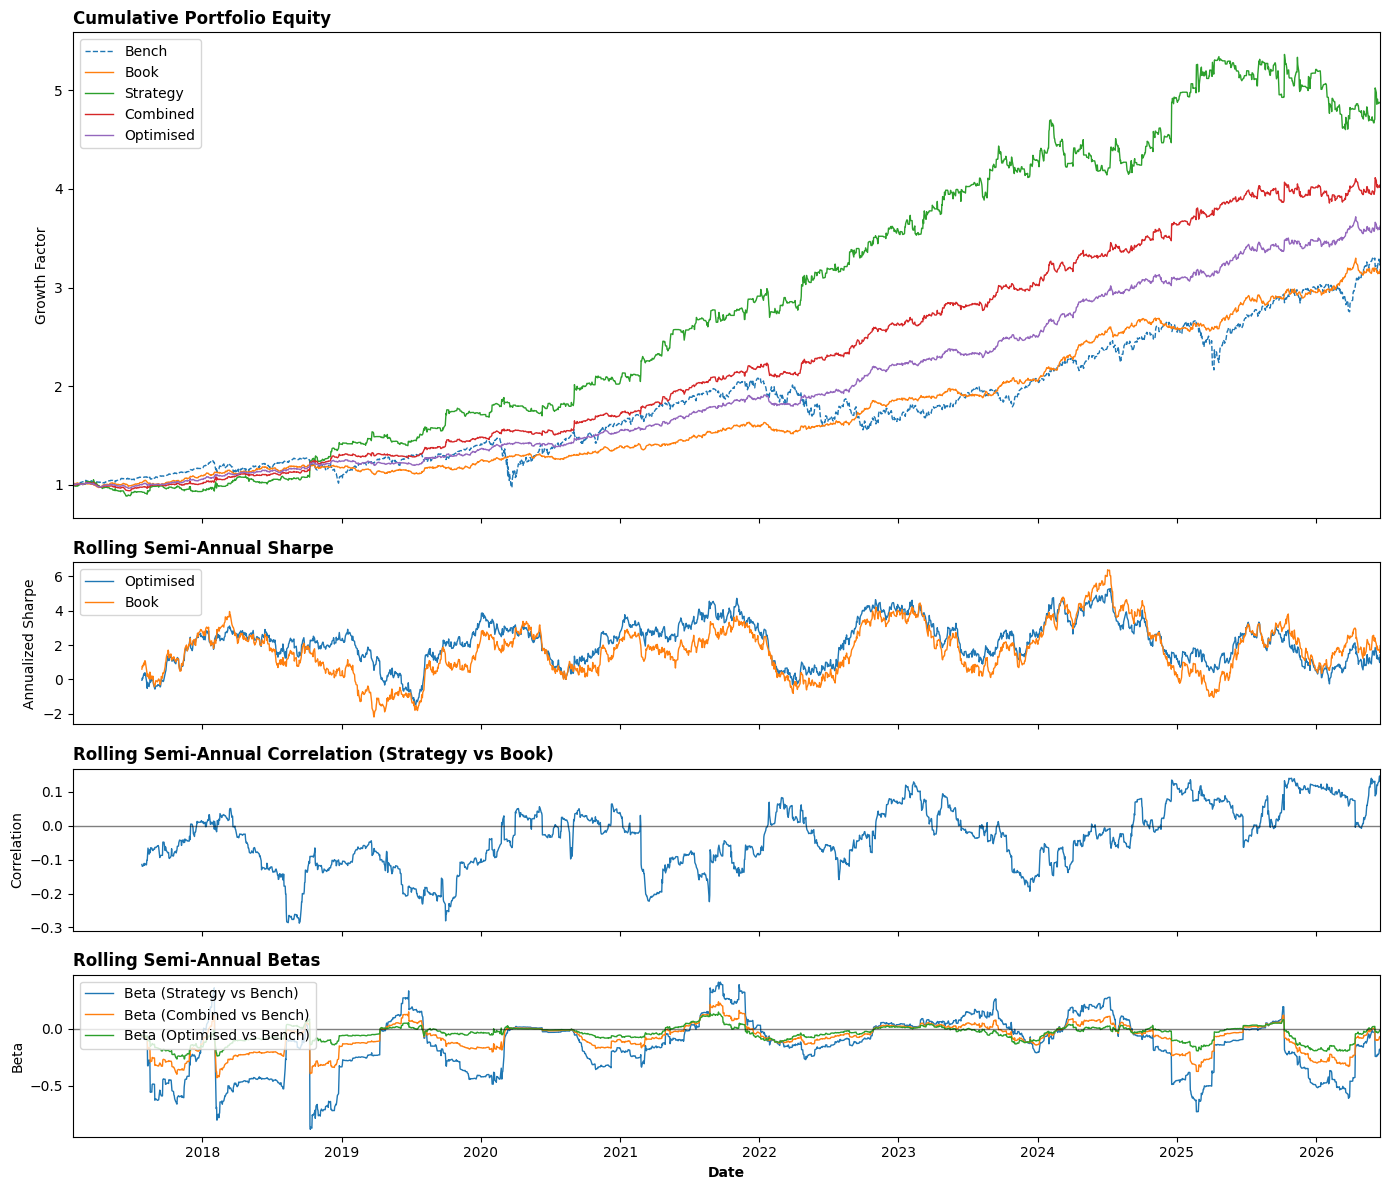

=== Portfolio Integration & Risk Report ===
                                 Book Strategy   Combined Optimised    Bench
Expected Return                12.63%   18.17%     15.29%    13.97%   14.30%
Volatility                      7.49%   16.07%      8.76%     6.78%   18.45%
Sharpe Ratio                     1.69     1.13       1.74      2.06     0.77
Beta                            -0.00    -0.10      -0.05     -0.03     1.00
Skewness                         0.02     2.58       1.94      0.46    -0.36
Kurtosis                        -0.09    20.65      14.68      2.19    14.94
Max Drawdown                   -8.14%  -15.81%     -8.37%    -5.94%  -34.23%
Max DD Days                       293      255        174       155      512
Max DD Recovery Days              177      195        108        41      103
Correlation to Book                 -    -0.03       0.40      0.82        -
Crash Correlation to Book           -    -0.06       0.12      0.45        -
Intraday Correlation to Book    

In [6]:
import random 

for _ in range(5):
    seed = random.randint(1, 10000)
    c = StrategyConnector(p, generate_toy_equity(p, expected_return=0.15, volatility=0.075, random_seed=seed), df["close"])
    
    print("SEED", seed)
    print(c.result())